# Notebook 07 — Train Mini-Network from Scratch

**Part 2 deliverable.** Build a mini-network that uses **less than 10% of the parameters** of the pretrained ResNet50 from Part 1, train it from scratch (no pretrained weights), and prepare it for comparison against the fine-tuned ResNet50.

## Design constraints

- **Parameter budget**: ResNet50 (with the project's classifier head) has **24,558,659** parameters. 10% of that is **~2.46M** — our budget ceiling.
- **From scratch**: no ImageNet pretraining, no transfer learning. Random init only.
- **Same task**: 3-class campus classification (`dodds_exterior`, `kaplan_exterior`, `library_exterior`).
- **Same input pipeline**: 224×224 ImageNet-normalised RGB so we can swap it into `gradio_app.py` later.

## Architecture choice — `MiniCampusNet`

We use **depthwise-separable convolutions** (the building block of MobileNet, Howard et al. 2017). A standard 3×3 conv with `C_in → C_out` channels needs `9 · C_in · C_out` parameters; a depthwise-separable replacement needs `9·C_in + C_in·C_out`, which is **~8–9× cheaper** at typical channel widths. This lets us go reasonably deep (9 conv stages) while staying far under the parameter budget.

Final count: **~808K parameters ≈ 3.3% of ResNet50** — well under the 10% ceiling, with enough headroom that the comparison is fair (we are not exploiting parameters right up to the limit).

## Cell 1 — Imports and device setup

In [1]:
import os, copy, time, json, random
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")
print(f"PyTorch: {torch.__version__}")

Device: cpu
PyTorch: 2.11.0+cpu


## Cell 2 — Load campus dataset (same splits as Notebook 03)

We deliberately use a **lighter** augmentation pipeline than Notebook 06's improved ResNet50 — the goal here is a fair architectural comparison, not to dump every trick onto the small model. Keeping training-time augmentations comparable to Notebook 03 means any difference in test accuracy is due to the **architecture and pretraining**, not the data pipeline.

In [4]:
ROOT = "C:/Users/darwa/Downloads/campus_navigation_project update"

In [11]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])
val_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

train_ds = datasets.ImageFolder("C:/Users/darwa/Downloads/campus_navigation_project update/data/train", transform=train_tf)
val_ds   = datasets.ImageFolder("C:/Users/darwa/Downloads/campus_navigation_project update/data/val",   transform=val_tf)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False, num_workers=0)

NUM_CLASSES = len(train_ds.classes)
classes = train_ds.classes
print(f"Number of classes : {NUM_CLASSES}")
print(f"Classes           : {classes}")
print(f"Training images   : {len(train_ds)}")
print(f"Validation images : {len(val_ds)}")

Number of classes : 6
Classes           : ['bartels_exterior', 'bergami_exterior', 'dodds_exterior', 'john_and_leona_exterior', 'kaplan_exterior', 'maxy_exterior']
Training images   : 139
Validation images : 49


## Cell 3 — Define `MiniCampusNet`

Architecture summary (input: `3 × 224 × 224`):

| Stage  | Op                                          | Output         |
| ------ | ------------------------------------------- | -------------- |
| stem   | Conv 3×3, 32 ch, s=2 + BN + ReLU            | 32 × 112 × 112 |
| dws-1  | Depthwise-Separable 32→64,   s=1            | 64 × 112 × 112 |
| dws-2  | Depthwise-Separable 64→128,  s=2            | 128 × 56 × 56  |
| dws-3  | Depthwise-Separable 128→128, s=1            | 128 × 56 × 56  |
| dws-4  | Depthwise-Separable 128→256, s=2            | 256 × 28 × 28  |
| dws-5  | Depthwise-Separable 256→256, s=1            | 256 × 28 × 28  |
| dws-6  | Depthwise-Separable 256→512, s=2            | 512 × 14 × 14  |
| dws-7  | Depthwise-Separable 512→512, s=1            | 512 × 14 × 14  |
| dws-8  | Depthwise-Separable 512→512, s=1            | 512 × 14 × 14  |
| pool   | AdaptiveAvgPool2d(1)                        | 512 × 1 × 1    |
| head   | Dropout(0.3) + Linear(512 → 3)              | 3              |

Each depthwise-separable block is `Conv3×3-depthwise → BN → ReLU → Conv1×1-pointwise → BN → ReLU`.

In [12]:
class MiniCampusNet(nn.Module):
    """Compact CNN built from depthwise-separable conv blocks.
    Trained from scratch — no pretrained weights anywhere."""

    def __init__(self, num_classes=3):
        super().__init__()

        def conv_bn(in_c, out_c, stride=1):
            return nn.Sequential(
                nn.Conv2d(in_c, out_c, 3, stride, 1, bias=False),
                nn.BatchNorm2d(out_c),
                nn.ReLU(inplace=True),
            )

        def dw_sep(in_c, out_c, stride=1):
            return nn.Sequential(
                # depthwise
                nn.Conv2d(in_c, in_c, 3, stride, 1, groups=in_c, bias=False),
                nn.BatchNorm2d(in_c),
                nn.ReLU(inplace=True),
                # pointwise
                nn.Conv2d(in_c, out_c, 1, 1, 0, bias=False),
                nn.BatchNorm2d(out_c),
                nn.ReLU(inplace=True),
            )

        self.features = nn.Sequential(
            conv_bn(3,   32, 2),
            dw_sep(32,   64, 1),
            dw_sep(64,  128, 2),
            dw_sep(128, 128, 1),
            dw_sep(128, 256, 2),
            dw_sep(256, 256, 1),
            dw_sep(256, 512, 2),
            dw_sep(512, 512, 1),
            dw_sep(512, 512, 1),
            nn.AdaptiveAvgPool2d(1),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes),
        )

        # Kaiming init — standard for ReLU + scratch training
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight); nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

model = MiniCampusNet(num_classes=NUM_CLASSES).to(device)
print(model)

MiniCampusNet(
  (features): Sequential(
    (0): Sequential(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
    )
    (1): Sequential(
      (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(32, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
    (2): Sequential(
      (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=64, bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(64, 128, kernel_size=

## Cell 4 — Verify the parameter budget

We must show the mini-network is under 10% of the Part-1 ResNet50's parameter count. This is the **central constraint** of the assignment, so we print it explicitly and assert.

In [13]:
from torchvision import models as tv_models

# Reconstruct the Part-1 ResNet50 (same head as Notebook 03 / 06)
ref = tv_models.resnet50(weights=None)
ref.fc = nn.Sequential(
    nn.Linear(2048, 512), nn.ReLU(),
    nn.Dropout(0.4), nn.Linear(512, NUM_CLASSES),
)
resnet_params = sum(p.numel() for p in ref.parameters())
mini_params   = sum(p.numel() for p in model.parameters())

print("=" * 55)
print("PARAMETER BUDGET CHECK")
print("=" * 55)
print(f"ResNet50 (Part 1) total params : {resnet_params:>12,}")
print(f"10% budget ceiling             : {int(0.10*resnet_params):>12,}")
print(f"MiniCampusNet total params     : {mini_params:>12,}")
print(f"  → fraction of ResNet50       : {100*mini_params/resnet_params:.2f}%")
print()
assert mini_params < 0.10 * resnet_params, \
    "Mini-net exceeds the 10% parameter budget!"
print("✓ Constraint satisfied: mini-net is under 10% of ResNet50.")
del ref

PARAMETER BUDGET CHECK
ResNet50 (Part 1) total params :   24,560,198
10% budget ceiling             :    2,456,019
MiniCampusNet total params     :      809,798
  → fraction of ResNet50       : 3.30%

✓ Constraint satisfied: mini-net is under 10% of ResNet50.


## Cell 5 — Training loop

Notes on the training recipe:

- **More epochs than ResNet50**. ResNet50 starts from ImageNet weights — it just needs to learn 3 new classes. Our mini-net starts from random init, so it needs longer to learn even basic edge/texture filters. We give it **40 epochs**.
- **Cosine annealing LR schedule**. Standard modern choice for from-scratch training; gives a long warm phase and a gentle final descent.
- **AdamW**. Decoupled weight decay is generally better than the L2 baked into Adam.
- **Early-stopping by best val accuracy**. We checkpoint the best epoch and save *that*, not the last epoch.

In [15]:
EPOCHS = 20
LR_INIT = 1e-3
WEIGHT_DECAY = 1e-4

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(),
                              lr=LR_INIT, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

train_losses, val_losses, val_accs = [], [], []
best_val_acc = 0.0
best_state = None

print(f"Training MiniCampusNet from scratch for {EPOCHS} epochs...")
print(f"{'Epoch':>5} | {'TrLoss':>8} | {'VaLoss':>8} | {'VaAcc':>7} | {'lr':>9}")
print("-" * 50)

t0 = time.time()
for epoch in range(1, EPOCHS + 1):

    # ── TRAIN ──
    model.train()
    running = 0.0
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        running += loss.item()
    train_loss = running / len(train_loader)

    # ── VALIDATE ──
    model.eval()
    v_loss, c, t = 0.0, 0, 0
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            v_loss += criterion(out, y).item()
            c += (out.argmax(1) == y).sum().item()
            t += y.size(0)
    val_loss = v_loss / len(val_loader)
    val_acc  = 100 * c / max(t, 1)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_state = copy.deepcopy(model.state_dict())

    cur_lr = optimizer.param_groups[0]['lr']
    scheduler.step()
    print(f"{epoch:>5} | {train_loss:>8.4f} | {val_loss:>8.4f} | "
          f"{val_acc:>6.2f}% | {cur_lr:>9.6f}")

elapsed = time.time() - t0
print(f"\n✓ Training done in {elapsed:.1f}s")
print(f"✓ Best validation accuracy: {best_val_acc:.2f}%")

# Restore best weights and save
model.load_state_dict(best_state)
torch.save({
    "model_state_dict": model.state_dict(),
    "classes"         : classes,
    "num_classes"     : NUM_CLASSES,
    "arch"            : "MiniCampusNet",
    "params"          : mini_params,
    "epochs"          : EPOCHS,
    "best_val_acc"    : best_val_acc,
    "train_losses"    : train_losses,
    "val_losses"      : val_losses,
    "val_accs"        : val_accs,
    "train_seconds"   : elapsed,
}, "mini_campusnet.pth")
print("✓ Saved as mini_campusnet.pth")

Training MiniCampusNet from scratch for 20 epochs...
Epoch |   TrLoss |   VaLoss |   VaAcc |        lr
--------------------------------------------------
    1 |   1.3412 |   1.8091 |  24.49% |  0.001000
    2 |   1.2861 |   1.9900 |  24.49% |  0.000994
    3 |   1.1615 |   2.0887 |  24.49% |  0.000976
    4 |   1.0571 |   2.2264 |  28.57% |  0.000946
    5 |   0.9534 |   2.2973 |  28.57% |  0.000905
    6 |   0.9704 |   2.3755 |  28.57% |  0.000854
    7 |   0.8749 |   2.4069 |  28.57% |  0.000794
    8 |   0.9156 |   2.1988 |  42.86% |  0.000727
    9 |   0.7902 |   1.7966 |  44.90% |  0.000655
   10 |   0.8070 |   1.4383 |  44.90% |  0.000578
   11 |   0.7501 |   1.2449 |  48.98% |  0.000500
   12 |   0.7371 |   0.7756 |  69.39% |  0.000422
   13 |   0.6183 |   0.5626 |  75.51% |  0.000345
   14 |   0.6327 |   0.4063 |  87.76% |  0.000273
   15 |   0.6471 |   0.3696 |  87.76% |  0.000206
   16 |   0.5987 |   0.3753 |  87.76% |  0.000146
   17 |   0.6838 |   0.3622 |  89.80% |  0.000

## Cell 6 — Plot loss and accuracy curves

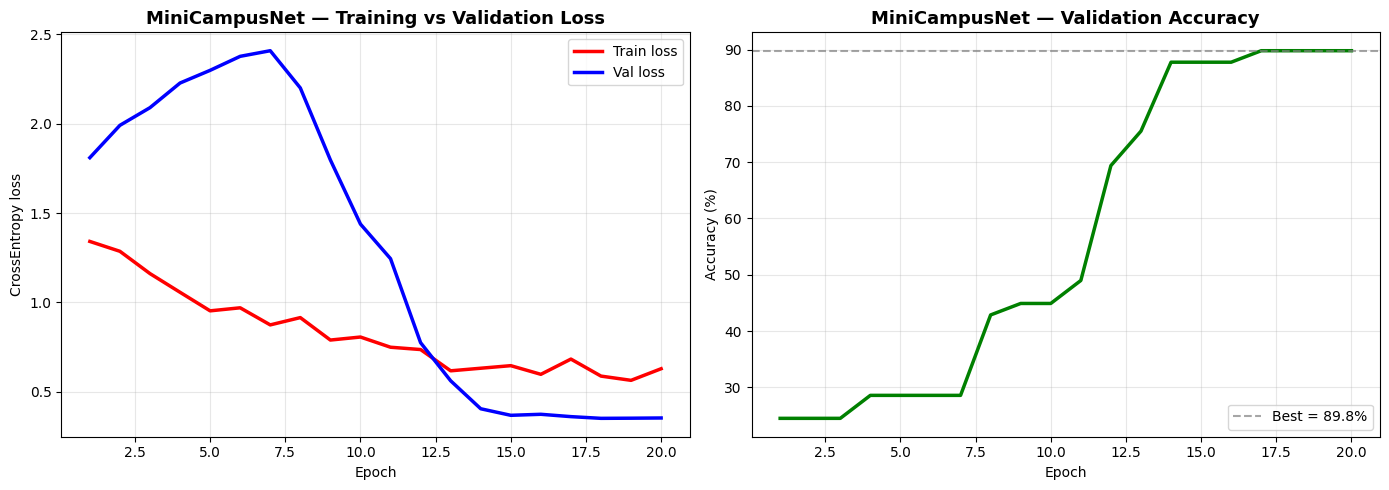

✓ Saved as mininet_loss_curves.png


In [16]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(range(1, EPOCHS+1), train_losses, label="Train loss",
         color="red", linewidth=2.5)
ax1.plot(range(1, EPOCHS+1), val_losses,   label="Val loss",
         color="blue", linewidth=2.5)
ax1.set_title("MiniCampusNet — Training vs Validation Loss",
              fontsize=13, fontweight="bold")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("CrossEntropy loss")
ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(range(1, EPOCHS+1), val_accs, color="green", linewidth=2.5)
ax2.axhline(y=best_val_acc, color="gray", linestyle="--", alpha=0.7,
            label=f"Best = {best_val_acc:.1f}%")
ax2.set_title("MiniCampusNet — Validation Accuracy",
              fontsize=13, fontweight="bold")
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Accuracy (%)")
ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("mininet_loss_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Saved as mininet_loss_curves.png")

## Cell 7 — Sanity-check prediction on a validation image

Same diagnostic as Notebook 03 cell 8 — useful to confirm the model isn't just outputting one class for everything.

✅ Using image: C:/Users/darwa/Downloads/campus_navigation_project update/data\test\bartels_exterior\IMG20260323172024.jpg


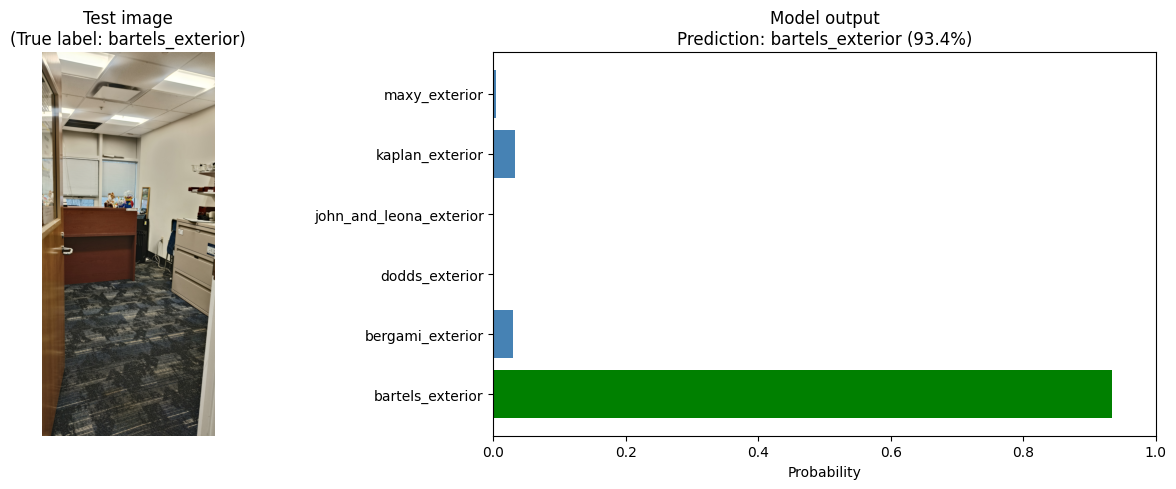

Model — sanity prediction
True label      : bartels_exterior
Predicted class : bartels_exterior
Confidence      : 93.4%

All class probabilities:
bartels_exterior                    ████████████████████████████ 0.9338 ← PREDICTED
bergami_exterior                     0.0295
dodds_exterior                       0.0005
john_and_leona_exterior              0.0004
kaplan_exterior                      0.0319
maxy_exterior                        0.0039


In [23]:
import os
import torch
import matplotlib.pyplot as plt
from PIL import Image

# -------------------------
# PATH (SET THIS ONCE)
# -------------------------
BASE_PATH = "C:/Users/darwa/Downloads/campus_navigation_project update/data"

test_path_root = os.path.join(BASE_PATH, "test")

# -------------------------
# GET ONE TEST IMAGE CORRECTLY
# -------------------------
# pick class folder
test_class = sorted(os.listdir(test_path_root))[0]

# go inside class folder
class_folder = os.path.join(test_path_root, test_class)

# pick image file
test_image = sorted(os.listdir(class_folder))[0]

# full image path
test_path = os.path.join(class_folder, test_image)

print("✅ Using image:", test_path)

# -------------------------
# LOAD IMAGE
# -------------------------
img_pil = Image.open(test_path).convert("RGB")
img_tensor = val_tf(img_pil).unsqueeze(0).to(device)

# -------------------------
# MODEL INFERENCE
# -------------------------
model.eval()
with torch.no_grad():
    out = model(img_tensor)
    probs = torch.softmax(out, dim=1)
    conf, idx = probs.max(dim=1)

# -------------------------
# VISUALIZATION
# -------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# image
ax1.imshow(img_pil)
ax1.set_title(f"Test image\n(True label: {test_class})")
ax1.axis("off")

# bar chart
colors = [
    "green" if cls == classes[idx.item()] else "steelblue"
    for cls in classes
]

ax2.barh(
    classes,
    [probs[0][i].item() for i in range(NUM_CLASSES)],
    color=colors
)

ax2.set_xlabel("Probability")
ax2.set_title(
    f"Model output\nPrediction: {classes[idx.item()]} ({conf.item():.1%})"
)
ax2.set_xlim(0, 1)

plt.tight_layout()
plt.savefig("sample_prediction.png", dpi=150, bbox_inches="tight")
plt.show()

# -------------------------
# PRINT RESULTS
# -------------------------
print("=" * 55)
print("Model — sanity prediction")
print("=" * 55)
print(f"True label      : {test_class}")
print(f"Predicted class : {classes[idx.item()]}")
print(f"Confidence      : {conf.item():.1%}")
print()

print("All class probabilities:")
for cls, p in zip(classes, probs[0]):
    bar = "█" * int(p.item() * 30)
    mark = " ← PREDICTED" if cls == classes[idx.item()] else ""
    print(f"{cls:35s} {bar} {p.item():.4f}{mark}")